# Setup Environment

In [ ]:
!pip install adjustText

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem
from scipy.stats import linregress, t
from scipy.spatial.distance import hamming
from scipy.stats import mannwhitneyu
import seaborn as sns
from adjustText import adjust_text

# Hyperparameters

In [ ]:
version = "1000ms"

In [ ]:
invalid_subjects = []
unnecessary_columns = []
if version == "1000ms":
    invalid_subjects = []
    # questions for practice trials
    unnecessary_columns =  ["Q113", "Q114", "Q115", "Q116", "Q117", "Q118", "Q119", "Q120", "Q121",
                 "Q140", "Q141", "Q142", "Q143", "Q144", "Q145", "Q146", "Q147", "Q148"]
    # columns for consent
    unnecessary_columns += ["Q18"]
    # columns for catch and demographics
    unnecessary_columns += ["Q266", "Q268", "Q269", "Q270"]
    unnecessary_columns += ["Q150", "Q181", "Q182"]
else:
    raise ValueError('version is not 1000ms!')

In [ ]:
invalid_subjects, unnecessary_columns

In [ ]:
scenes = ["Ball", "Supermarket", "Zoo", "Candle", "Shoe"]
# colors = ["dimgray", "gold", "lightseagreen", "tomato", "royalblue"]
colors = ["#E64E53", "#AA7C00", "#818A00", "#AD7291", "#2E9284"]
textcolor="#3F5661"
graycolor="#758D99"

In [ ]:
# ticks labels to be displayed in bar plot
property_dict = {
 'Q1': 'Ball color',
 'Q3': 'Ball size',
 'Q4': 'Ball trajectory',
 'Q5': 'Table color',
 'Q6': 'Table size',
 'Q7': 'Table shape',
 'Q8': "Person's height",
 'Q9': "Person's hair color",
 'Q10': "Person's gender",

 'Q11': 'Fruit kind',
 'Q12': 'Fruit size',
 'Q13': 'Which hand',
 'Q14': 'Bag size',
 'Q15': 'Bag color',
 'Q16': 'How held bag',
 'Q17': "Person's age",
 'Q18.1': "Person's build",
 'Q19': "Person's clothes",

 'Q20': 'Animal kind',
 'Q21': 'Animal size',
 'Q22': 'Treat kind',
 'Q23': 'Cage spacing',
 'Q24': 'Which hand',
 'Q25': 'Relative location',
 'Q26': "Person's age",
 'Q27': "Person's build",
 'Q28': "Person's clothes",

 'Q29': 'Candle size',
 'Q31': 'Candle color',
 'Q32': 'Holder shape',
 'Q33': 'Holder material',
 'Q34': 'How lit candle',
 'Q35': 'Which hand',
 'Q36': "Person's age",
 'Q37': "Person's build",
 'Q30': "Person's clothes",

 'Q38': 'Bench size',
 'Q40': 'Bench color',
 'Q41': "Whether socks",
 'Q42': 'Whether sitting',
 'Q43': 'Shoe kind',
 'Q44': 'Which shoe',
 'Q45': "Person's age",
 'Q46': "Person's build",
 'Q39': "Person's clothes"}

In [ ]:
# to match column names in original paper data
datacol_dict = {
 'Q1': 'ball_color',
 'Q3': 'ball_size',
 'Q4': 'ball_traj',
 'Q5': 'table_color',
 'Q6': 'table_size',
 'Q7': 'table_shape',
 'Q8': "person_height",
 'Q9': "person_hair",
 'Q10': "person_gender",

 'Q11': 'fruit_kind',
 'Q12': 'fruit_size',
 'Q13': 'fruit_hand',
 'Q14': 'bag_size',
 'Q15': 'bag_color',
 'Q16': 'bag_hold',
 'Q17': "person_age",
 'Q18.1': "person_build",
 'Q19': "person_clothes",

 'Q20': 'animal_kind',
 'Q21': 'animal_size',
 'Q22': 'treat_kind',
 'Q23': 'cage_space',
 'Q24': 'person_hand',
 'Q25': 'person_location',
 'Q26': "person_age",
 'Q27': "person_build",
 'Q28': "person_clothes",

 'Q29': 'candle_size',
 'Q31': 'candle_color',
 'Q32': 'holder_shape',
 'Q33': 'holder_material',
 'Q34': 'lit_how',
 'Q35': 'lit_hand',
 'Q36': "person_age",
 'Q37': "person_build",
 'Q30': "person_clothes",

 'Q38': 'bench_size',
 'Q40': 'bench_color',
 'Q41': "person_sock",
 'Q42': 'person_sit',
 'Q43': 'shoe_kind',
 'Q44': 'shoe_which',
 'Q45': "person_age",
 'Q46': "person_build",
 'Q39': "person_clothes"}

In [ ]:
# the question ids associated with each scene
scene_question_dict = {
    'Ball': ['Q1', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10'],
    'Supermarket': ['Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18.1', 'Q19'],
    'Zoo': ['Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28'],
    'Candle': ['Q29', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'Q30'],
    'Shoe': ['Q38', 'Q40', 'Q41', 'Q42', 'Q43', 'Q44', 'Q45', 'Q46', 'Q39'],
}

# Load Perception Data

In [ ]:
# de-identified, post-exclusion data: one row per analysed participant
df = pd.read_csv('exp2_clean.csv', dtype=str)
df.head()


In [ ]:
# Drop the page-timing columns
cols_to_drop = [col for col in df.columns if col.endswith(('First Click', 'Last Click', 'Page Submit', 'Click Count'))]
df.drop(cols_to_drop, axis=1, inplace=True)
df.head()


# Process Data and Meta Stats

In [ ]:
# Exclusions were applied before this file was saved; every row finished the study
print(df.shape)
print(f'Number of participants after exclusion: {df.shape[0]}')


In [ ]:
# Completion time
print(f"Completion time (minutes) mean {df['Duration (in seconds)'].astype(float).mean()/60}, \
      median {df['Duration (in seconds)'].astype(float).median()/60}")

Completion time (minutes) mean 5.085889774236388,       median 4.0


In [ ]:
# Age
# convert age column to float, marking errors as nan
df['Q181'] = pd.to_numeric(df['Q181'], errors='coerce')
print(f"Age mean {df['Q181'].astype(float).mean()}, \
      median {df['Q181'].astype(float).median()}, \
      unanswered {df['Q181'].astype(float).isna().sum()}")

Age mean 39.96690070210632,       median 37.0,       unanswered 7


In [ ]:
# Gender
print(f"Gender unanswered {df['Q182'].isnull().sum()}")
# distribution of gender answers
df['Q182'].value_counts()

Gender unanswered 4


,count
Q182,
Female,489
Male,489
Non-binary / third gender,20
Prefer not to say,2


In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                 'one second', 'one-second', '1 second', '1 sec', '1 SECOND', '1 SEC', 'a second',
                'notice', 'noticing', 'NOTICING', 'Noticing', 'NOTICE', 'Notice',
                'details', 'DETAILS', 'Details',
                 'characteristics',
                 'specific items', 'certain objects',
                 'look at', 'Look at', 'looked at', 'looking at', 'Looking at', 'saw the pic',
                 'in the picture', 'in a picture', 'in pictures', 'in each picture',
                 'was shown a picture',
                 'recall', 'Recall', 'RECALL', 'memory',
                 'answer questions', 'Answer questions', 'answering questions', 'questions about', 'answer related questions', 'answered questions',
                'remember', 'Remember', 'memorize', 'Memorize',
                 'yes or no', 'yes/no', 'yes no', 'whether or not i saw', 'y/n', 'noted or not',
                 'attention to', 'attentions to', 'pay attention', 'paying attention', 'focused on', 'focus on',
                 'describe', 'Describe', 'Describing',
                 'what i saw', 'what I saw', 'what i see', 'what objects',
                 'identify', 'Identify',
                 'observing', 'observe', 'observation', 'observant', 'Observation',
                 'after viewing an', 'viewing a image', 'picture viewing',
                 'PERCEPTION', 'Perception',
                 'brief', 'Brief',
                 'short', 'SHORT',
                 'quick',
                 'rate',
                 'Studying photos',
                 'analyze  photos',
                 'opinions on pictures',
                 'judging images',
                 'on a image',
                 'view object',
                ]
tmpdf = df[~df['Q266'].str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q266'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
print('invalid subjects', len(invalid_subjects))

In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                'color', 'COLOR', 'Color',
                'size', 'SIZE',
                'shape',
                'candle', 'CANDLE',
                'hair',
                'person', 'human', 'people', 'man',
                'build', 'physique',
                'height',
                'gender',
                'age',
                'hand', 'HAND',
                'clothing', 'clothes',
                'sock',
                'standing',
                'shoe',
                'bench',
                'treat', 'snack',
                'animal',
                'giraffe',
                'spacing',
                'fruit', 'FRUIT',
                'bag',
                'material',
                'texture',
                'pattern',
                'table',
                'surface',
                'trajectory',
                'direction',
                'motion', 'moving', 'movement',
                'position',
                'location',
                'what the object was', 'what are the', 'what objects',

                'number of', 'how many',
                'blue object', 'blue box',
                'indoor', 'outdoor', 'inside or outside',
                'sitting on', 'what the object was on', 'what x was on',
                'cloud',
                'refrigerator', 'fridge', 'refigeratot',
                'beach',
                'background',
                ]
tmpdf = df[~df['Q268'].astype(str).str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q268'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
print('invalid subjects', len(invalid_subjects))

In [ ]:
# filter catch questions that do not contain certain strings
valid_strings = [
                'blue', 'Blue', 'BLUE',
                'Blie', 'bleu', 'Bule', 'BLue',
                ]
tmpdf = df[~df['Q269'].astype(str).str.contains('|'.join(valid_strings))]
for i in range(len(tmpdf)):
  print(tmpdf['Q269'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
print('invalid subjects', len(invalid_subjects))

In [ ]:
# filter catch questions that do not contain certain strings
# Convert 'Q270' column to numeric, handling errors
df['Q270'] = pd.to_numeric(df['Q270'], errors='coerce')
tmpdf = df[~(df['Q270'] == 6)]
for i in range(len(tmpdf)):
  print(tmpdf['Q270'].iloc[i])

invalid_subjects += tmpdf['participant'].tolist()
print('invalid subjects', len(invalid_subjects))

In [ ]:
# drop rows of invalid subjects
print(df.shape)
print('invalid subjects:', len(invalid_subjects))
df = df[~df['participant'].isin(invalid_subjects)]
print(df.shape)

In [ ]:
# Only keep columns that start with "Q"
cols_to_keep = [col for col in df.columns if (col.startswith('Q'))]
df = df[cols_to_keep]
df.head()

In [ ]:
# drop unnecessary columns
df.drop(unnecessary_columns, axis=1, inplace=True)
print(df.shape)
df.head()

(994, 45)


,Q1,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,...,Q30,Q38,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q39
2,Yes,Yes,No,No,Yes,Yes,No,No,Yes,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Convert responses to float values
df.replace("Yes", 1, inplace=True)
df.replace("No", 0, inplace=True)
df.head()

<ipython-input-24-8c905964a7af>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("No", 0, inplace=True)


,Q1,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,...,Q30,Q38,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q39
2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Calculate mean values

In [ ]:
print(df.shape)
print(df.columns)
# Calculate the sum of each column
mean_values = df.mean(skipna=True) * 100
mean_values

(994, 45)
Index(['Q1', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12',
       'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18.1', 'Q19', 'Q20', 'Q21', 'Q22',
       'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q31', 'Q32', 'Q33',
       'Q34', 'Q35', 'Q36', 'Q37', 'Q30', 'Q38', 'Q40', 'Q41', 'Q42', 'Q43',
       'Q44', 'Q45', 'Q46', 'Q39'],
      dtype='object')


,0
Q1,82.000000
Q3,96.000000
Q4,79.000000
Q5,81.500000
Q6,65.000000
Q7,65.500000
Q8,51.000000
Q9,95.000000
Q10,98.000000
Q11,88.205128


# Plot No%

<ipython-input-26-965e3426c7e0>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
<ipython-input-26-965e3426c7e0>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
<ipython-input-26-965e3426c7e0>:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_for_subplot = percentage_zeros[sorted_indices]
<ipython-input-26-965e3426c7e0>:22

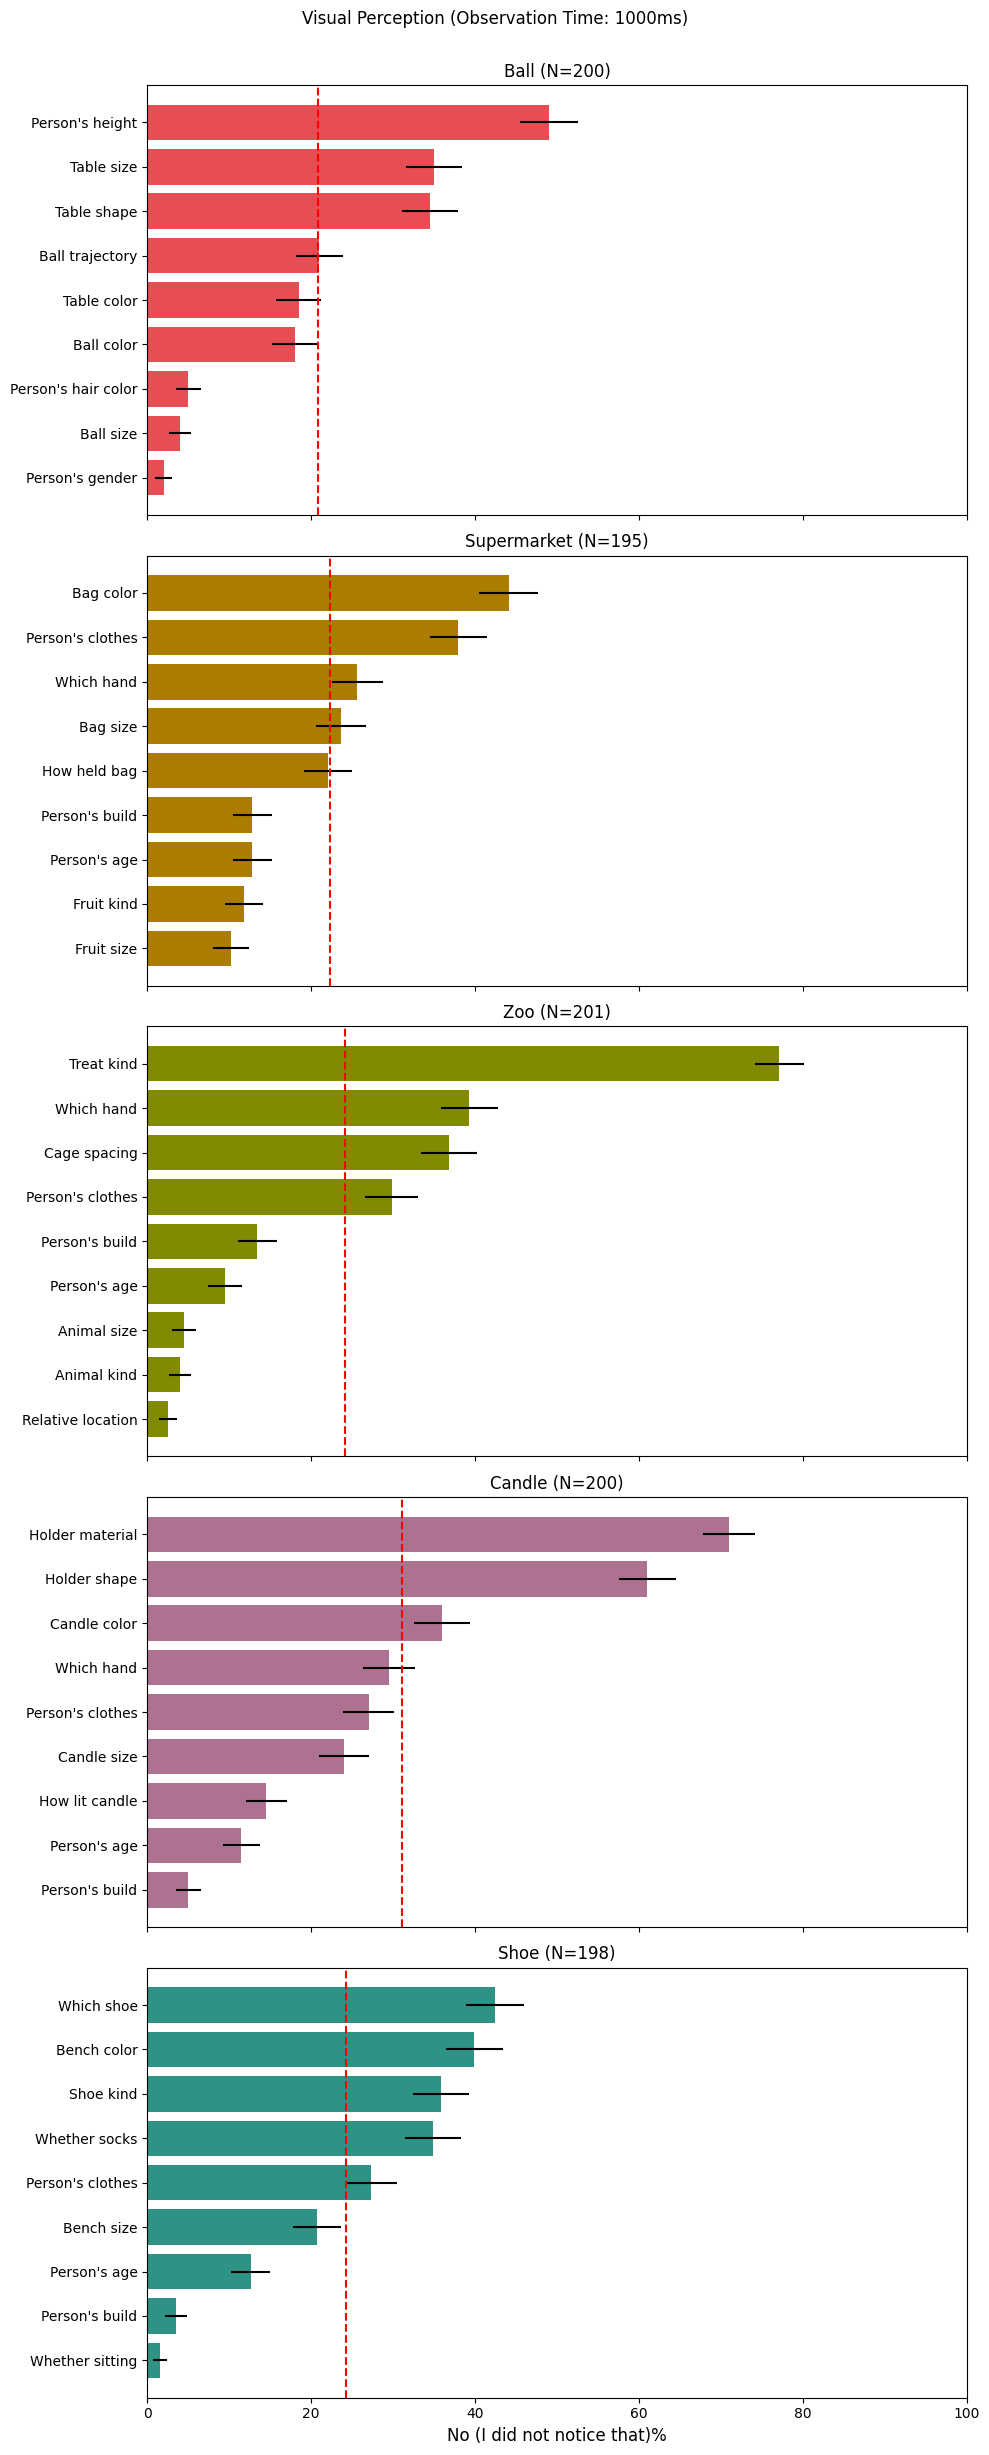

In [ ]:
# No%, sorted

# Prepare figure for subplots
fig, axs = plt.subplots(len(scenes), 1, figsize=(10, 5*len(scenes)), sharex=True)  # 5 Rows, 1 Column

for i in range(len(scenes)):
    # Data for this subplot
    start_index = i * 9
    end_index = start_index + 9

    current_data = df.iloc[:, start_index:end_index].copy()
    # Drop NaN values from the current data
    current_data_nonan = current_data.dropna()

    # Calculate the percentage of 0's after dropping NaNs
    percentage_zeros = (current_data_nonan == 0).sum() / current_data_nonan.count() * 100
    # Calculate SEM, adjusting for the actual number of non-NaN observations
    sem_values = sem((current_data_nonan == 0) * 100, axis=0)

    # Sort the data, SEM values, and labels in descending order
    sorted_indices = percentage_zeros.argsort() # Get indices to sort in descending order
    data_for_subplot = percentage_zeros[sorted_indices]
    sem_values = sem_values[sorted_indices]

    current_index_section = current_data.columns[sorted_indices]  # Use original column names
    final_labels = [property_dict.get(label, label) for label in current_index_section]

    # y-coordinates for bars, after sorting
    y = range(len(data_for_subplot))

    # Plotting horizontal bars for this subplot
    axs[i].barh(y, data_for_subplot, color=colors[i], xerr=sem_values)

    # Set y-ticks and labels for this subplot
    axs[i].set_yticks(y)
    axs[i].set_yticklabels(final_labels)

    # Optional: Add dashed line for average or other stylistic choices
    avg = data_for_subplot.mean()
    axs[i].axvline(x=avg, color='red', linestyle='dashed', label='Average' if i==0 else '')  # label only on the first subplot

    # Optional: Add titles or labels
    axs[i].set_title(scenes[i]+" (N="+str(len(current_data_nonan))+")")

    # set x-axis range
    axs[i].set_xlim(0, 100)


# Adjust layout
plt.xlabel("No (I did not notice that)%", fontsize=12)
plt.tight_layout()
fig.suptitle("Visual Perception (Observation Time: "+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title
plt.show()


# Save to temporary mini data files

In [ ]:
for i in range(len(scenes)):
    # Define the start and end index for slicing the DataFrame
    start_index = i * 9
    end_index = start_index + 9

    # Slice the DataFrame to get 9 columns
    df_slice = df.iloc[:, start_index:end_index]
    df_slice = df_slice.dropna() # drop nan rows
    df_slice = df_slice.astype(int)

    # Replace the column names in the slice with names from property_dict
    df_slice.columns = [datacol_dict.get(col, col) for col in df_slice.columns]

    # Define the filename for the current slice
    filename = 'formaldata_'+version+'_'+scenes[i]+'.csv'

    # Save the slice to a CSV file
    df_slice.to_csv(filename, index=False)

    print(f'Saved {filename}')

Saved formaldata_1000ms_Ball.csv
Saved formaldata_1000ms_Supermarket.csv
Saved formaldata_1000ms_Zoo.csv
Saved formaldata_1000ms_Candle.csv
Saved formaldata_1000ms_Shoe.csv


# Plot correlation of old and new, 1 scene per row


Scene:  Ball
Slope: 0.06683157574968537
Intercept: 18.5500585861216
R-squared: 0.00823474809877441
p-value: 0.81639866184563
Standard error: 0.27721196140316956
95% CI for slope: -0.5886705510158523, 0.722333702515223
95% CI for intercept: 18.135262303628583, 18.96485486861462


<ipython-input-28-119d8f6c41d7>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
<ipython-input-28-119d8f6c41d7>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
<ipython-input-28-119d8f6c41d7>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
<ipython-input-28-119d8f6c41d7>:60: FutureWarning: Series.__get


Scene:  Supermarket
Slope: 0.4275911831727952
Intercept: 6.403491784738113
R-squared: 0.5144777478921204
p-value: 0.029615347388248777
Standard error: 0.15700048474999448
95% CI for slope: 0.056344029421135144, 0.7988383369244553
95% CI for intercept: 6.1323367216192075, 6.674646847857019


<ipython-input-28-119d8f6c41d7>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
<ipython-input-28-119d8f6c41d7>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
<ipython-input-28-119d8f6c41d7>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
<ipython-input-28-119d8f6c41d7>:60: FutureWarning: Series.__get


Scene:  Zoo
Slope: 0.4905254091300603
Intercept: 5.3104417619053805
R-squared: 0.22944643428627318
p-value: 0.1920339930381868
Standard error: 0.33976078346785366
95% CI for slope: -0.3128811791981912, 1.2939319974583119
95% CI for intercept: 4.783437419011018, 5.837446104799743


<ipython-input-28-119d8f6c41d7>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
<ipython-input-28-119d8f6c41d7>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
<ipython-input-28-119d8f6c41d7>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
<ipython-input-28-119d8f6c41d7>:60: FutureWarning: Series.__get


Scene:  Candle
Slope: -0.4899676885107488
Intercept: 48.71497694356043
R-squared: 0.20742460899452894
p-value: 0.21797126721387378
Standard error: 0.3620000017835637
95% CI for slope: -1.3459616718047946, 0.36602629478329707
95% CI for intercept: 48.112989252832115, 49.316964634288745


<ipython-input-28-119d8f6c41d7>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
<ipython-input-28-119d8f6c41d7>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
<ipython-input-28-119d8f6c41d7>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
<ipython-input-28-119d8f6c41d7>:60: FutureWarning: Series.__get


Scene:  Shoe
Slope: 0.5346379534418936
Intercept: 4.219915602612076
R-squared: 0.2704980582650137
p-value: 0.15119686603490792
Standard error: 0.3318500716905829
95% CI for slope: -0.25006277397046284, 1.31933868085425
95% CI for intercept: 3.4815733495288517, 4.9582578556953


<ipython-input-28-119d8f6c41d7>:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
<ipython-input-28-119d8f6c41d7>:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_y_pred = y_pred[sorted_indices]
<ipython-input-28-119d8f6c41d7>:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sorted_ci = ci[sorted_indices]
<ipython-input-28-119d8f6c41d7>:60: FutureWarning: Series.__get

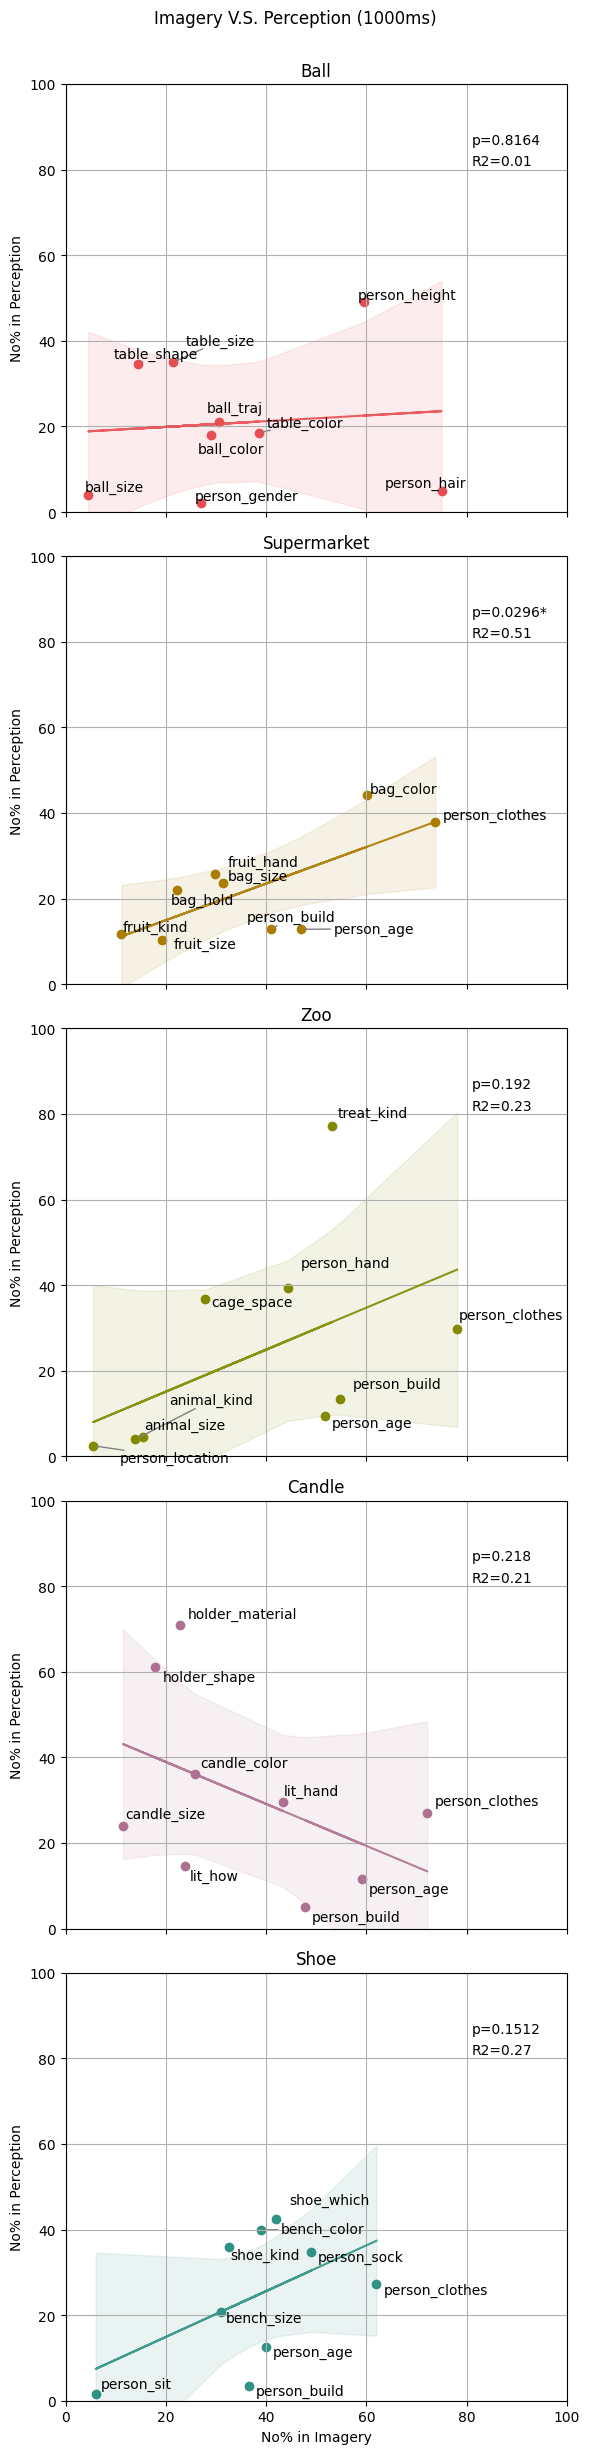

In [ ]:
# Prepare figure for subplots
nrows = len(scenes)
# nrows = 2
fig, axs = plt.subplots(nrows, 1, figsize=(6, 5*nrows), sharex=True)  # 5 Rows, 1 Column

for scene_idx in range(nrows):
    print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf

    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    # scatter plot of the means
    axs[scene_idx].scatter(avg_zeros_olddf, avg_zeros_newdf, color=colors[scene_idx])

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(avg_zeros_olddf, avg_zeros_newdf)
    # Plot the regression line
    axs[scene_idx].plot(avg_zeros_olddf, intercept + slope * avg_zeros_olddf, label=f'y={slope:.2f}x+{intercept:.2f}', color=colors[scene_idx], alpha=0.9)
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(avg_zeros_olddf) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * avg_zeros_olddf # Predicted values
    se = np.sqrt(np.sum((avg_zeros_newdf - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(avg_zeros_olddf) + (avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2)) # Confidence interval calculation
    # Sort the values by avg_zeros_olddf to ensure proper filling
    sorted_indices = np.argsort(avg_zeros_olddf)
    sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[scene_idx].fill_between(sorted_avg_zeros_olddf, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color=colors[scene_idx], alpha=0.1, label='95% CI')
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}')

    axs[-1].set_xlabel('No% in Imagery')
    axs[scene_idx].set_ylabel('No% in Perception')
    axs[scene_idx].set_title(scenes[scene_idx])
    texts = []
    for i, txt in enumerate(avg_zeros_olddf.index): # Annotate each point with its column name
        texts.append(axs[scene_idx].annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i])))
    # Use adjust_text to repel text annotations from each other
    adjust_text(texts, ax=axs[scene_idx], force_static=(1,1), force_text=(2,1), force_pull=(0.1,0.1), min_arrow_len=10, arrowprops=dict(arrowstyle='->', color='gray'))

    # axs[scene_idx].legend(loc='upper left')
    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xlim(0,100)
    axs[scene_idx].grid(True)

    # annotate p-value and R
    txt = 'p='+str(round(p_value, 4))
    if p_value < 0.001:
        txt += '***'
    elif p_value < 0.01:
        txt += '**'
    elif p_value < 0.05:
        txt += '*'
    axs[scene_idx].annotate(txt, (81,86))
    axs[scene_idx].annotate('R2='+str(round(r_value**2, 2)), (81,81))


plt.tight_layout()
fig.suptitle("Imagery V.S. Perception ("+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title


# plot correlation of old and new, 1 scene per column

Text(0.5, -0.04, 'No% in Imagery')

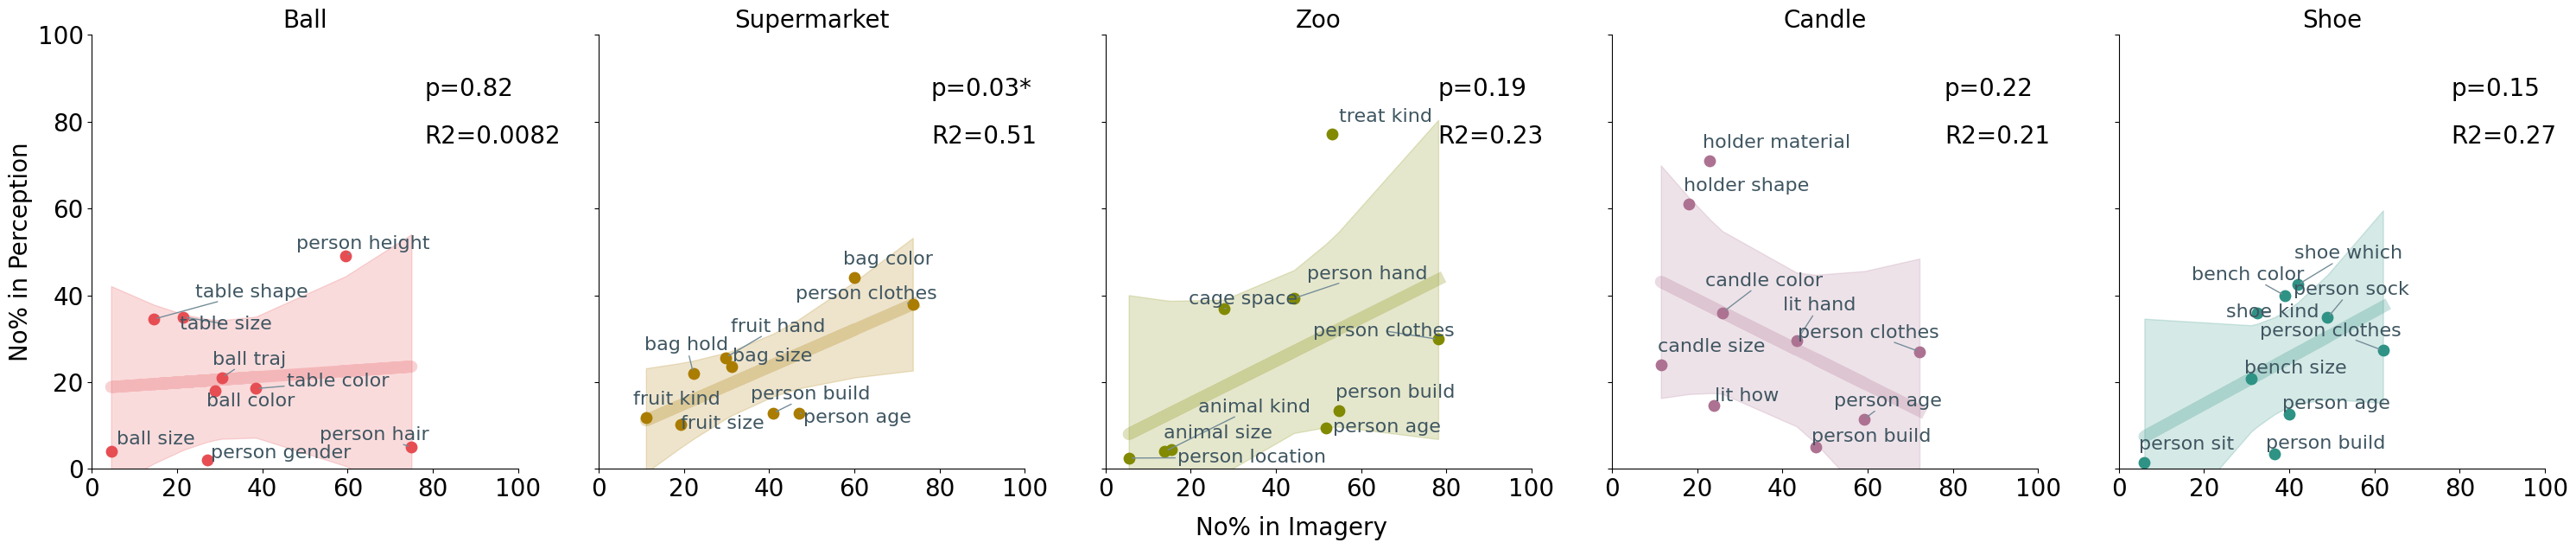

In [ ]:
# suppress warning
import warnings
warnings.filterwarnings('ignore')

# Prepare figure for subplots
ncols = len(scenes)
fig, axs = plt.subplots(1, ncols, figsize=(6*ncols, 6), sharey=True)  # 5 Rows, 1 Column

for scene_idx in range(ncols):
    # print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf
    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    # scatter plot of the means
    axs[scene_idx].scatter(avg_zeros_olddf, avg_zeros_newdf,
                           color=colors[scene_idx], s=80, alpha=1)

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(avg_zeros_olddf, avg_zeros_newdf)
    # Plot the regression line
    axs[scene_idx].plot(avg_zeros_olddf, intercept + slope * avg_zeros_olddf,
                        label=f'y={slope:.2f}x+{intercept:.2f}',
                        color=colors[scene_idx], alpha=0.25, lw=10)

    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(avg_zeros_olddf) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * avg_zeros_olddf # Predicted values
    se = np.sqrt(np.sum((avg_zeros_newdf - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(avg_zeros_olddf) + (avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2)) # Confidence interval calculation
    # Sort the values by avg_zeros_olddf to ensure proper filling
    sorted_indices = np.argsort(avg_zeros_olddf)
    sorted_avg_zeros_olddf = avg_zeros_olddf[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[scene_idx].fill_between(sorted_avg_zeros_olddf, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci,
                                color=colors[scene_idx], alpha=0.2,
                                label='95% CI')

    # print(f'Slope: {slope}')
    # print(f'Intercept: {intercept}')
    # print(f'R-squared: {r_value**2}')
    # print(f'p-value: {p_value}')
    # print(f'Standard error: {std_err}')
    # print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    # print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(avg_zeros_olddf) + np.mean(avg_zeros_olddf)**2 / np.sum((avg_zeros_olddf - np.mean(avg_zeros_olddf)) ** 2))}')

    axs[0].set_ylabel('No% in Perception', fontsize=20)
    axs[scene_idx].set_title(scenes[scene_idx], fontsize=20)
    texts = []
    for i, txt in enumerate(avg_zeros_olddf.index): # Annotate each point with its column name
        txt = txt.replace('_', ' ') # remove underscore
        texts.append(axs[scene_idx].annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i]), fontsize=16, color=textcolor))
    # Use adjust_text to repel text annotations from each other
    adjust_text(texts, ax=axs[scene_idx],
                force_static=(5,10), force_text=(5,10), # force_pull=(0.1,0.1),
                min_arrow_len=10, arrowprops=dict(arrowstyle='->', color=graycolor))

    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xlim(0,100)
    axs[scene_idx].spines['top'].set_visible(False) # no top border
    axs[scene_idx].spines['right'].set_visible(False) # no right border
    axs[scene_idx].tick_params(axis='both', labelsize=20)

    # annotate p-value and R
    txt = f'p={p_value:.2g}'
    if p_value < 0.001:
        txt += '***'
    elif p_value < 0.01:
        txt += '**'
    elif p_value < 0.05:
        txt += '*'
    axs[scene_idx].annotate(txt, (78,86), fontsize=20)
    axs[scene_idx].annotate(f'R2={r_value**2:.2g}', (78,75), fontsize=20)

plt.tight_layout()
fig.text(0.5, -0.04, 'No% in Imagery', ha='center', fontsize=20)


# Plot bar of old and new, 1 scene per row


Scene:  Ball


<ipython-input-148-ac4e452fa537>:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:dimgray'` for the same effect.

  sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])
<ipython-input-148-ac4e452fa537>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
<ipython-input-148-ac4e452fa537>:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gold'` for the same effect.

  sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])



Scene:  Supermarket


<ipython-input-148-ac4e452fa537>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
<ipython-input-148-ac4e452fa537>:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightseagreen'` for the same effect.

  sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])



Scene:  Zoo


<ipython-input-148-ac4e452fa537>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
<ipython-input-148-ac4e452fa537>:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:tomato'` for the same effect.

  sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])



Scene:  Candle


<ipython-input-148-ac4e452fa537>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
<ipython-input-148-ac4e452fa537>:31: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:royalblue'` for the same effect.

  sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])



Scene:  Shoe


<ipython-input-148-ac4e452fa537>:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)


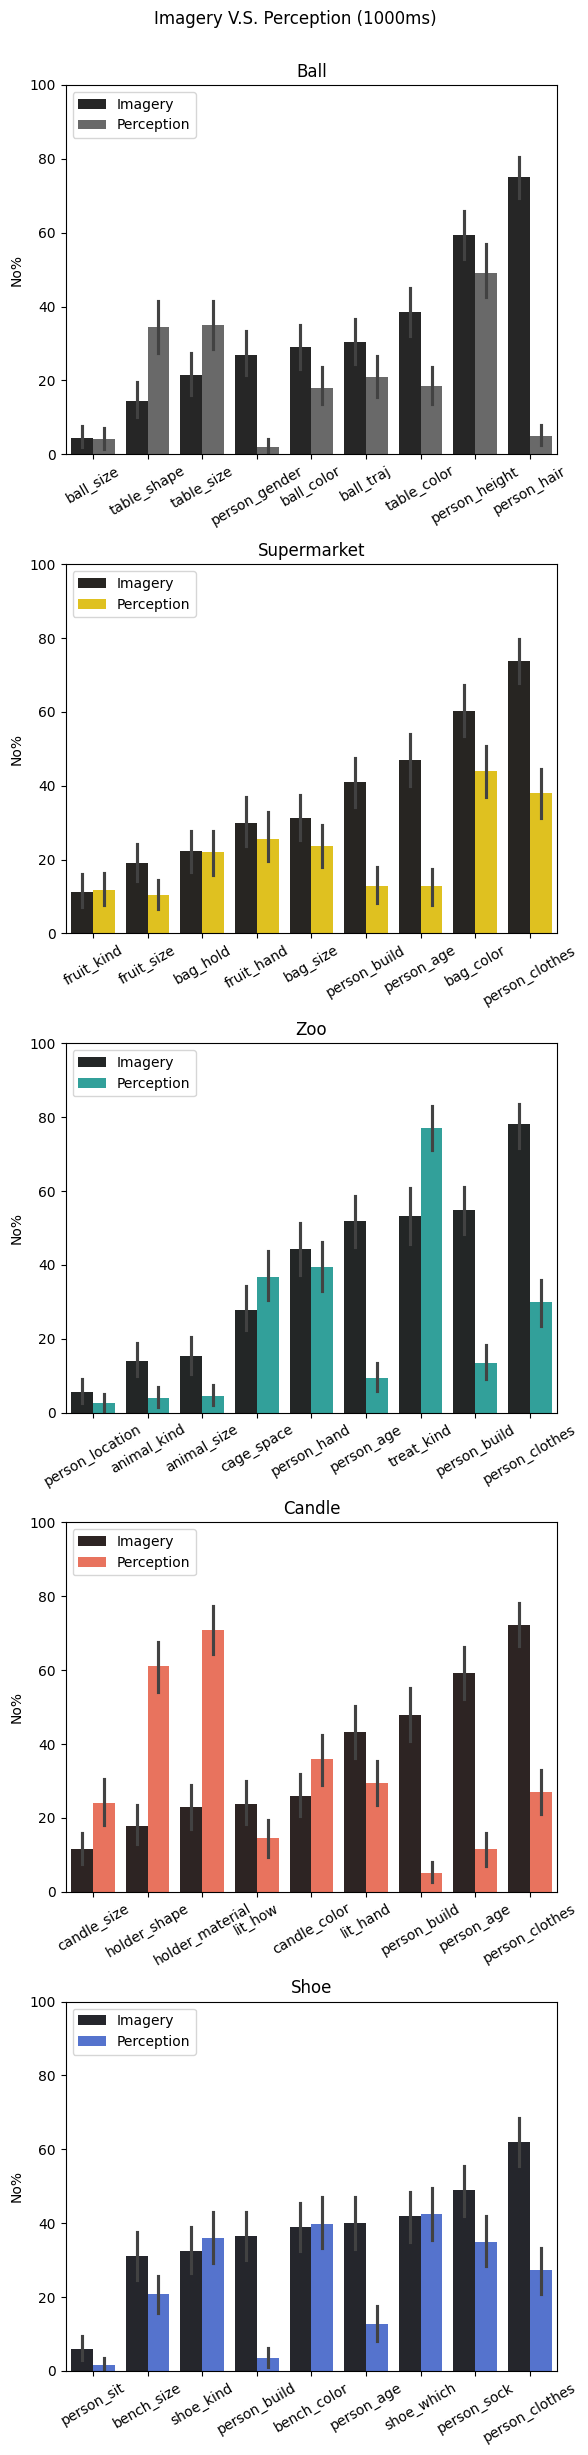

In [ ]:
# Prepare figure for subplots
nrows = len(scenes)
# nrows = 2
fig, axs = plt.subplots(nrows, 1, figsize=(6, 5*nrows))  # 5 Rows, 1 Column

for scene_idx in range(nrows):
    print('\nScene: ', scenes[scene_idx])
    # load data from old and new exp
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)
    newdf = newdf[olddf.columns] # Align the columns of newdf with olddf

    tmpdf1 = (olddf.copy() == 0)*100
    tmpdf2 = (newdf.copy() == 0)*100
    sorted_columns = tmpdf1.columns[tmpdf1.mean().argsort()]
    tmpdf1 = tmpdf1[sorted_columns]
    tmpdf1["Exp"] = "Imagery"
    tmpdf2 = tmpdf2[sorted_columns]
    tmpdf2["Exp"] = "Perception"
    aggdf = pd.concat([tmpdf1, tmpdf2], ignore_index=True)
    longdf = aggdf.melt(id_vars=['Exp'], var_name='Property', value_name='No%')
    sns.barplot(data=longdf, x='Property', y='No%', hue='Exp', legend='auto', ax=axs[scene_idx], color=colors[scene_idx])
    axs[scene_idx].set_ylim(0,100)
    axs[scene_idx].set_xticklabels(axs[scene_idx].get_xticklabels(), rotation=30)
    axs[scene_idx].set_xlabel('')
    axs[scene_idx].legend(loc='upper left')
    axs[scene_idx].set_title(scenes[scene_idx])


plt.tight_layout()
fig.suptitle("Imagery V.S. Perception ("+version+")")
plt.subplots_adjust(top=0.95)  # Adjust the top padding to make space for the main title
plt.show()

# Plot correlation of all scenes

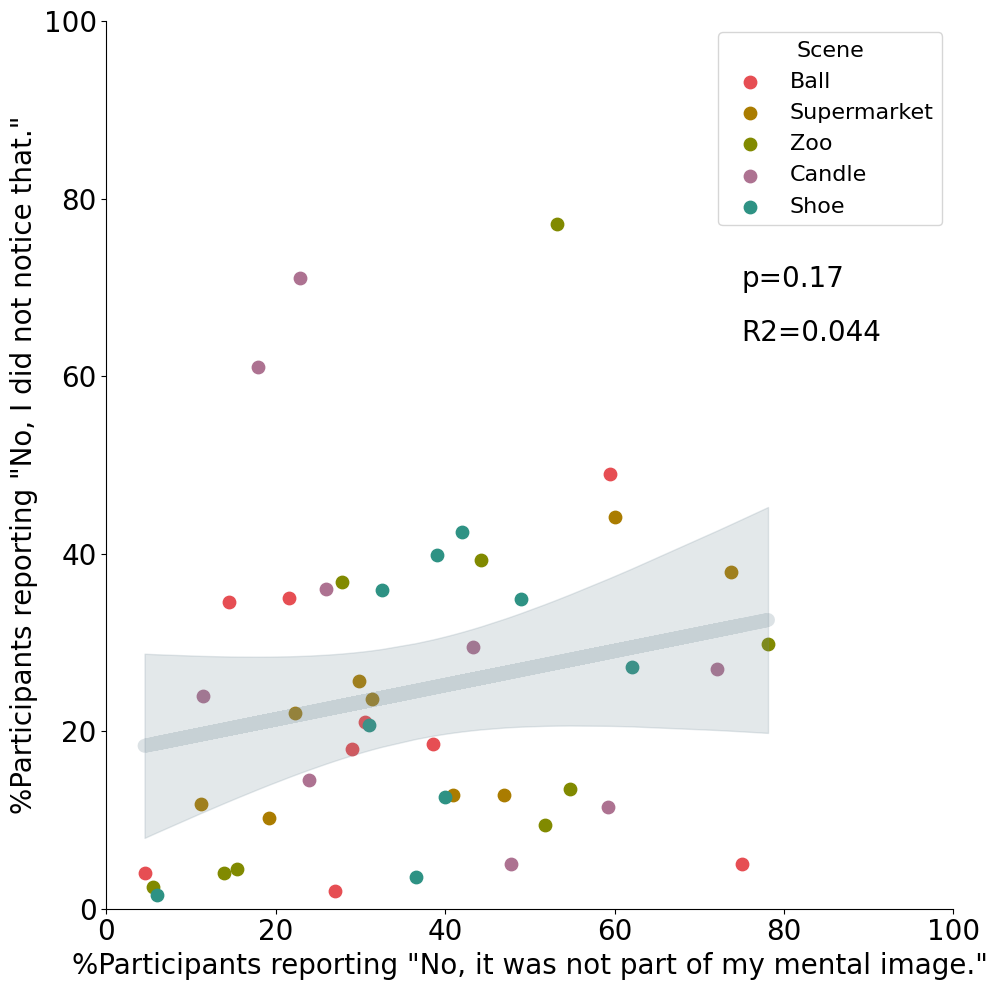

In [ ]:
plt.figure(figsize=(10,10))
all_scores_old = []
all_scores_new = []
labels = []

for scene_idx in range(len(scenes)):
    newdf = pd.read_csv('formaldata_'+version+'_'+scenes[scene_idx]+'.csv')
    olddf = pd.read_csv('exp_1.csv')
    if scene_idx!=0:
        olddf = pd.read_csv('exp_2.csv')
        matching_rows = olddf[olddf['scene'] == scenes[scene_idx].lower()] # select matching rows for the particular scene
        matching_rows = matching_rows.dropna(axis=1, how='all') # drop columns that do not contain value (properties from other scenes)
        olddf = matching_rows
        olddf.columns = [col.split('.')[0] for col in olddf.columns] # clear column names
        olddf = olddf.drop(columns=["scene"])
    olddf = olddf.drop(columns=["time"])
    olddf = olddf.astype(int)

    # Align the columns of newdf with olddf
    newdf = newdf[olddf.columns]

    # Calculate the average number of 0s for each column
    avg_zeros_olddf = (olddf == 0).mean() * 100
    avg_zeros_newdf = (newdf == 0).mean() * 100

    all_scores_old += avg_zeros_olddf.tolist()
    all_scores_new += avg_zeros_newdf.tolist()

    # Create scatter plot
    plt.scatter(avg_zeros_olddf, avg_zeros_newdf,
                label=scenes[scene_idx],
                color=colors[scene_idx], s=80, alpha=1)

    # # Annotate each point with its column name
    # for i, txt in enumerate(avg_zeros_olddf.index):
    #     labels.append(plt.annotate(txt, (avg_zeros_olddf[i], avg_zeros_newdf[i])))

# # Use adjust_text to repel text annotations from each other
# adjust_text(labels, force_static=(1,1), force_text=(1,1), force_pull=(0.1,0.1), min_arrow_len=10, arrowprops=dict(arrowstyle='->', color='gray'))

all_scores_old = np.array(all_scores_old)
all_scores_new = np.array(all_scores_new)
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(all_scores_old, all_scores_new)
# Plot the regression line
plt.plot(all_scores_old, intercept + slope * all_scores_old,
         color=graycolor, alpha=0.25, lw=10)

# Calculate the confidence intervals
confidence_interval = 0.95  # 95% confidence interval
degrees_freedom = len(all_scores_old) - 2  # Degrees of freedom
t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
# Predicted values
y_pred = intercept + slope * all_scores_old
# Standard error of the regression
se = np.sqrt(np.sum((all_scores_new - y_pred) ** 2) / degrees_freedom)
# Confidence interval calculation
ci = t_crit * se * np.sqrt(1/len(all_scores_old) + (all_scores_old - np.mean(all_scores_old)) ** 2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))
# Sort the values by all_scores_old to ensure proper filling
sorted_indices = np.argsort(all_scores_old)
sorted_all_scores_old = all_scores_old[sorted_indices]
sorted_y_pred = y_pred[sorted_indices]
sorted_ci = ci[sorted_indices]
# Plotting the confidence interval
plt.fill_between(sorted_all_scores_old, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci,
                 color=graycolor, alpha=0.2)

# # Show statistical values
# print(f'Slope: {slope}')
# print(f'Intercept: {intercept}')
# print(f'R-squared: {r_value**2}')
# print(f'p-value: {p_value}')
# print(f'Standard error: {std_err}')
# print(f'95% confidence interval for the slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
# print(f'95% confidence interval for the intercept: {intercept - t_crit * std_err * np.sqrt(1/len(all_scores_old) + np.mean(all_scores_old)**2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(all_scores_old) + np.mean(all_scores_old)**2 / np.sum((all_scores_old - np.mean(all_scores_old)) ** 2))}')

# annotate p-value and R
txt = f'p={p_value:.2g}'
if p_value < 0.001:
    txt += '***'
elif p_value < 0.01:
    txt += '**'
elif p_value < 0.05:
    txt += '*'
plt.annotate(txt, (75,70), fontsize=20)
plt.annotate(f'R2={r_value**2:.2g}', (75,64), fontsize=20)

# Add labels and title
plt.xlabel('%Participants reporting "No, it was not part of my mental image."', fontsize=20)
plt.ylabel('%Participants reporting "No, I did not notice that."', fontsize=20)
plt.tick_params(axis='both', labelsize=20)
plt.legend(loc='upper right', frameon=True, title='Scene', fontsize=16, title_fontsize=16)

plt.ylim(0,100)
plt.xlim(0,100)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

# Vividness

In [ ]:
df = pd.read_csv('exp_4a.csv')
df.head()

,fruit_kind,fruit_size,fruit_hand,bag_color,bag_size,bag_held,person_age,person_build,person_clothes,vviq_friend_1,...,suis_8,suis_9,suis_10,suis_11,suis_12,suis_total,nc_total,order_nc_first,order_suis_first,time
0,1,1,1,1,1,1,1,1,0,4,...,5,3,3,2,3,43,8,False,False,359
1,1,1,1,1,1,1,1,1,0,5,...,5,3,3,4,5,47,8,True,True,242
2,1,1,1,0,1,1,1,1,0,3,...,4,3,3,4,5,44,7,True,False,441
3,0,0,1,1,1,0,0,1,0,4,...,4,3,3,4,3,43,4,False,False,285
4,1,1,1,0,1,1,0,1,0,2,...,4,3,3,2,4,38,6,True,False,450


In [ ]:
df4b = pd.read_csv('exp_4b.csv')
df4b.head()

,fruit_kind,fruit_size,fruit_hand,bag_color,bag_size,bag_held,person_age,person_build,person_clothes,nc_total,scene_clarity,time
0,0,0,0,0,0,0,0,0,0,0,7,90
1,1,1,1,1,1,1,0,1,0,7,6,102
2,1,1,0,0,0,0,0,0,0,2,2,92
3,1,1,0,0,0,0,1,1,1,5,5,73
4,1,0,1,0,0,1,1,0,0,4,3,122


Slope: 0.004036297637149288
Intercept: 0.5801462070845217
R-squared: 0.013890744313649171
p-value: 0.041353236180408266
Standard error: 0.001970038939912485
95% CI for slope: 0.00015934668729703253, 0.007913248587001542
95% CI for intercept: 0.5791002755935163, 0.5811921385755271
Slope: 0.0026558812792247454
Intercept: 0.6884483574758556
R-squared: 0.0022159366129700132
p-value: 0.41656920055708047
Standard error: 0.00326467640625068
95% CI for slope: -0.0037688598960619124, 0.009080622454511404
95% CI for intercept: 0.6862974078734484, 0.6905993070782629
Slope: 0.05193215207906675
Intercept: 0.5516872940966973
R-squared: 0.02501191387292789
p-value: 0.0249399183429356
Standard error: 0.022984548348011332
95% CI for slope: 0.006607621547589183, 0.09725668261054432
95% CI for intercept: 0.5333665910664571, 0.5700079971269374
Slope: 0.005005691265747319
Intercept: 0.36147803486776137
R-squared: 0.014846709930339656
p-value: 0.034900670663571186
Standard error: 0.002362069775436399
95% CI

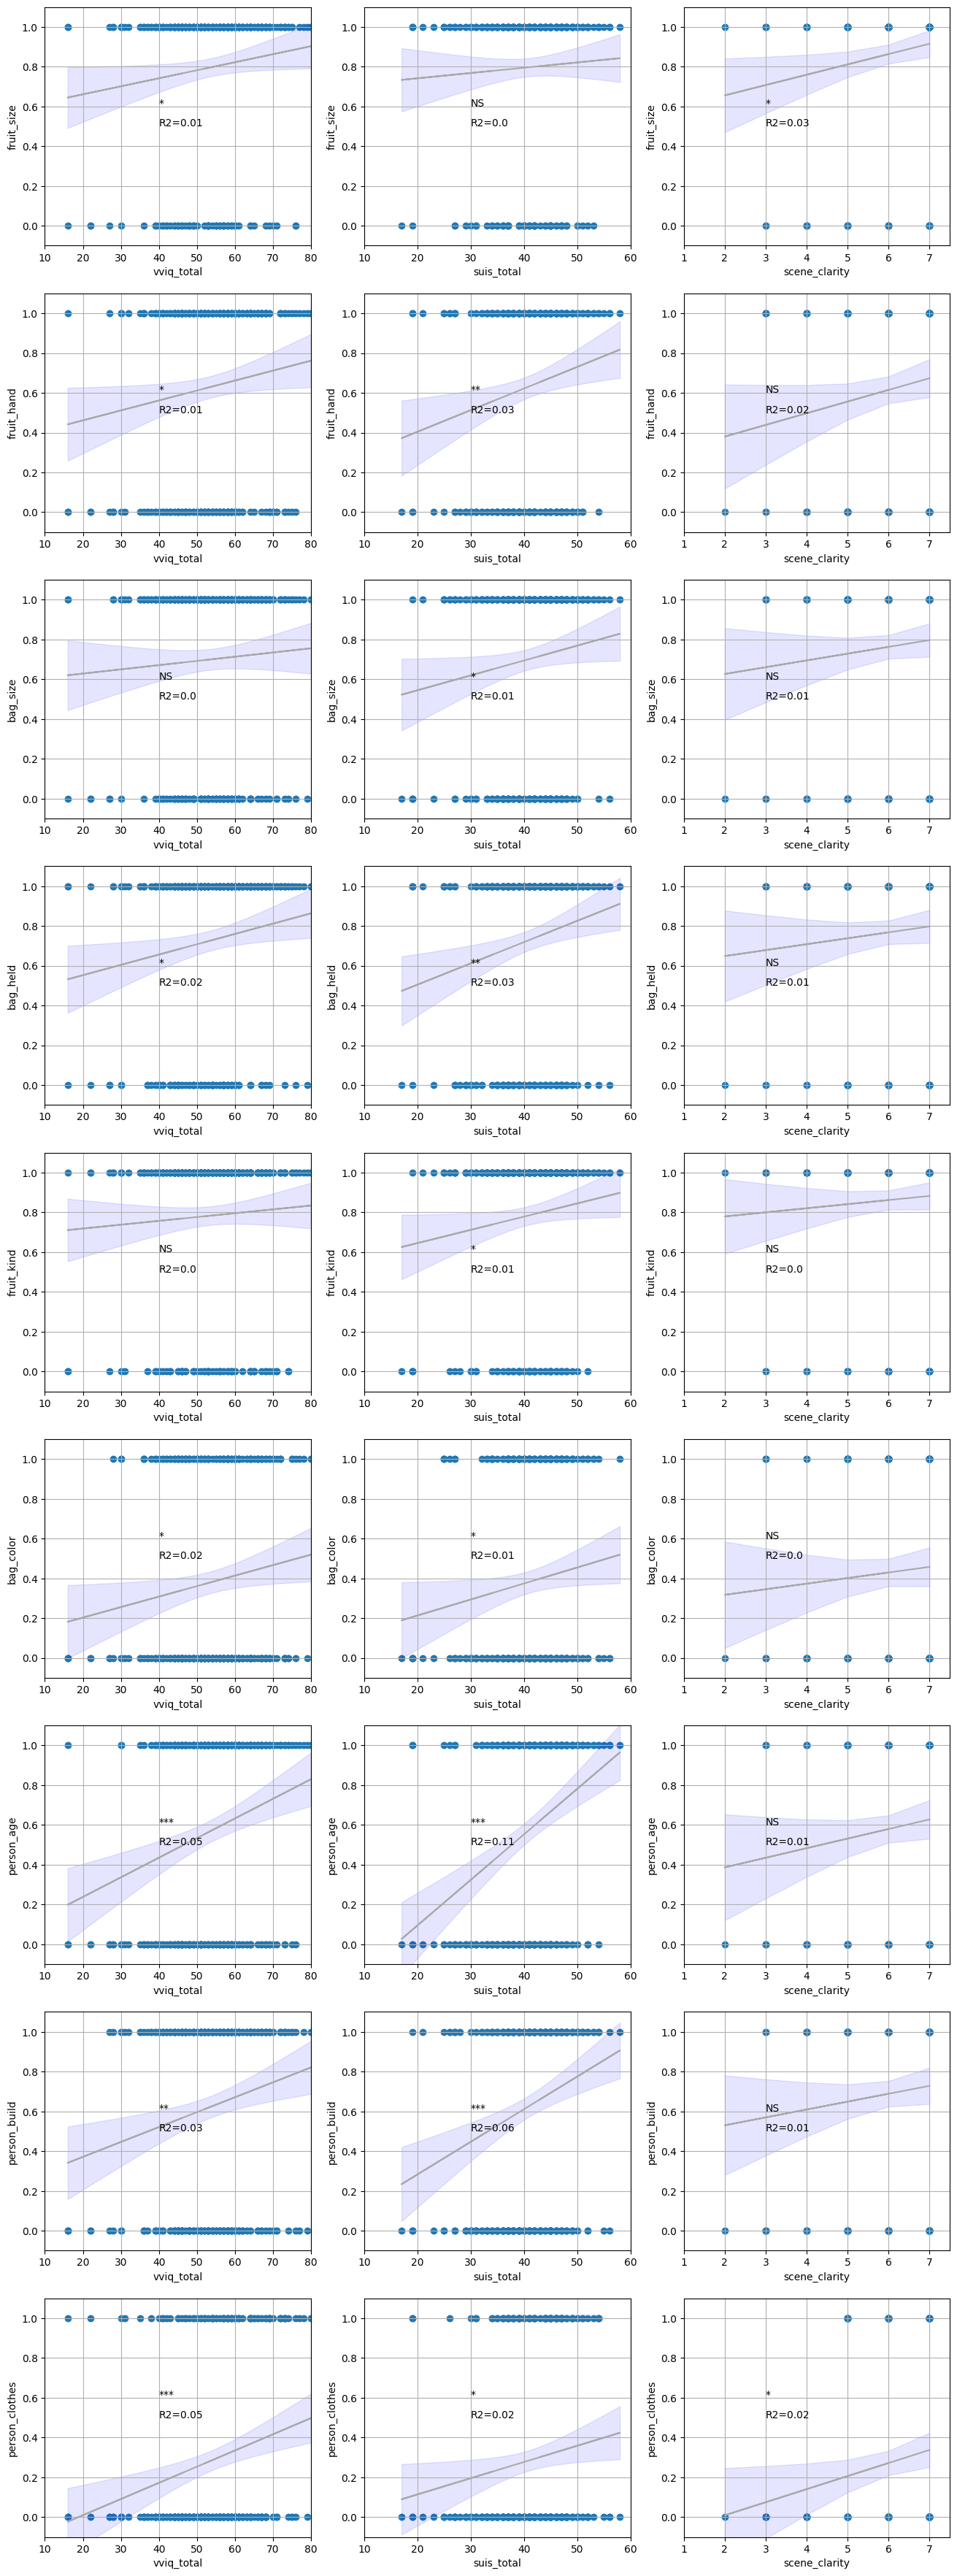

In [ ]:
properties = ['fruit_size', 'fruit_hand', 'bag_size', 'bag_held', 'fruit_kind', 'bag_color', 'person_age', 'person_build', 'person_clothes']
nrows = len(properties)
fig, axs = plt.subplots(nrows, 3, figsize=(16, 5*nrows))  # 5 Rows, 1 Column

for iproperty in range(nrows):
    xdata = df['vviq_total']
    ydata = df[properties[iproperty]]
    axs[iproperty][0].scatter(xdata, ydata)
    axs[iproperty][0].set_xlabel('vviq_total')
    axs[iproperty][0].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][0].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][0].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][0].annotate('***', (40, 0.6))
    elif p_value < 0.01:
        axs[iproperty][0].annotate('**', (40, 0.6))
    elif p_value < 0.05:
        axs[iproperty][0].annotate('*', (40, 0.6))
    else:
        axs[iproperty][0].annotate('NS',(40, 0.6))
    axs[iproperty][0].annotate('R2='+str(round(r_value**2, 2)),(40, 0.5))
    axs[iproperty][0].set_ylim(-0.1,1.1)
    axs[iproperty][0].set_xlim(10,80)
    axs[iproperty][0].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')

    xdata = df['suis_total']
    axs[iproperty][1].scatter(xdata, ydata)
    axs[iproperty][1].set_xlabel('suis_total')
    axs[iproperty][1].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][1].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][1].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][1].annotate('***', (30, 0.6))
    elif p_value < 0.01:
        axs[iproperty][1].annotate('**', (30, 0.6))
    elif p_value < 0.05:
        axs[iproperty][1].annotate('*', (30, 0.6))
    else:
        axs[iproperty][1].annotate('NS', (30, 0.6))
    axs[iproperty][1].annotate('R2='+str(round(r_value**2,2)), (30, 0.5))
    axs[iproperty][1].set_ylim(-0.1,1.1)
    axs[iproperty][1].set_xlim(10,60)
    axs[iproperty][1].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')

    xdata = df4b['scene_clarity']
    ydata = df4b[properties[iproperty]]
    axs[iproperty][2].scatter(xdata, ydata)
    axs[iproperty][2].set_xlabel('scene_clarity')
    axs[iproperty][2].set_ylabel(properties[iproperty])
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(xdata, ydata)
    # Plot the regression line
    axs[iproperty][2].plot(xdata, intercept + slope * xdata, label=f'y={slope:.2f}x+{intercept:.2f}', color='darkgray')
    # calculate 95% confidence interval
    confidence_interval = 0.95
    degrees_freedom = len(xdata) - 2  # Degrees of freedom
    t_crit = np.abs(t.ppf((1 - confidence_interval) / 2, degrees_freedom))  # t-critical value for 95% CI
    y_pred = intercept + slope * xdata # Predicted values
    se = np.sqrt(np.sum((ydata - y_pred) ** 2) / degrees_freedom) # Standard error of the regression
    ci = t_crit * se * np.sqrt(1/len(xdata) + (xdata - np.mean(xdata)) ** 2 / np.sum((xdata - np.mean(xdata)) ** 2)) # Confidence interval calculation
    # Sort the values by xdata to ensure proper filling
    sorted_indices = np.argsort(xdata)
    sorted_xdata = xdata[sorted_indices]
    sorted_y_pred = y_pred[sorted_indices]
    sorted_ci = ci[sorted_indices]
    # Plotting the confidence interval
    axs[iproperty][2].fill_between(sorted_xdata, sorted_y_pred - sorted_ci, sorted_y_pred + sorted_ci, color='b', alpha=0.1, label='95% CI')
    if p_value < 0.001:
        axs[iproperty][2].annotate('***', (3, 0.6))
    elif p_value < 0.01:
        axs[iproperty][2].annotate('**', (3, 0.6))
    elif p_value < 0.05:
        axs[iproperty][2].annotate('*', (3, 0.6))
    else:
        axs[iproperty][2].annotate('NS', (3, 0.6))
    axs[iproperty][2].annotate('R2='+str(round(r_value**2,2)), (3, 0.5))
    axs[iproperty][2].set_ylim(-0.1,1.1)
    axs[iproperty][2].set_xlim(1,7.5)
    axs[iproperty][2].grid(True)
    print(f'Slope: {slope}')
    print(f'Intercept: {intercept}')
    print(f'R-squared: {r_value**2}')
    print(f'p-value: {p_value}')
    print(f'Standard error: {std_err}')
    print(f'95% CI for slope: {slope - t_crit * std_err}, {slope + t_crit * std_err}')
    print(f'95% CI for intercept: {intercept - t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}, {intercept + t_crit * std_err * np.sqrt(1/len(xdata) + np.mean(xdata)**2 / np.sum((xdata - np.mean(xdata)) ** 2))}')




# Show the plot
plt.show()